In [2]:
from google.colab import files
uploaded = files.upload()

Saving store.csv to store.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [20]:
train = pd.read_csv('train.csv',low_memory=False)
store = pd.read_csv('store.csv')
test = pd.read_csv('test.csv')

In [21]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [23]:
train.isnull().sum()
store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


In [24]:
data = pd.merge(train, store, on='Store', how='left')

In [25]:
data.head()
data.shape

(1017209, 18)

In [26]:
data['Date'] = pd.to_datetime(data['Date'])

In [27]:
data = data.sort_values(by='Date')

In [28]:
data['Sales'].describe()

,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04


<Axes: >

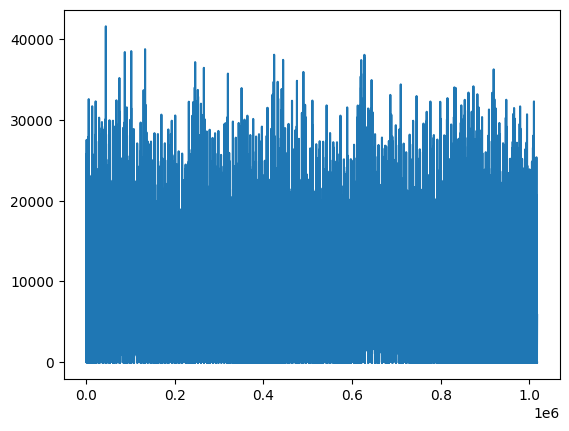

In [29]:
data['Sales'].plot()

In [30]:
data = data[data['Open'] == 1]
data = data[data['Sales'] > 0]

In [31]:
data.shape

(844338, 18)

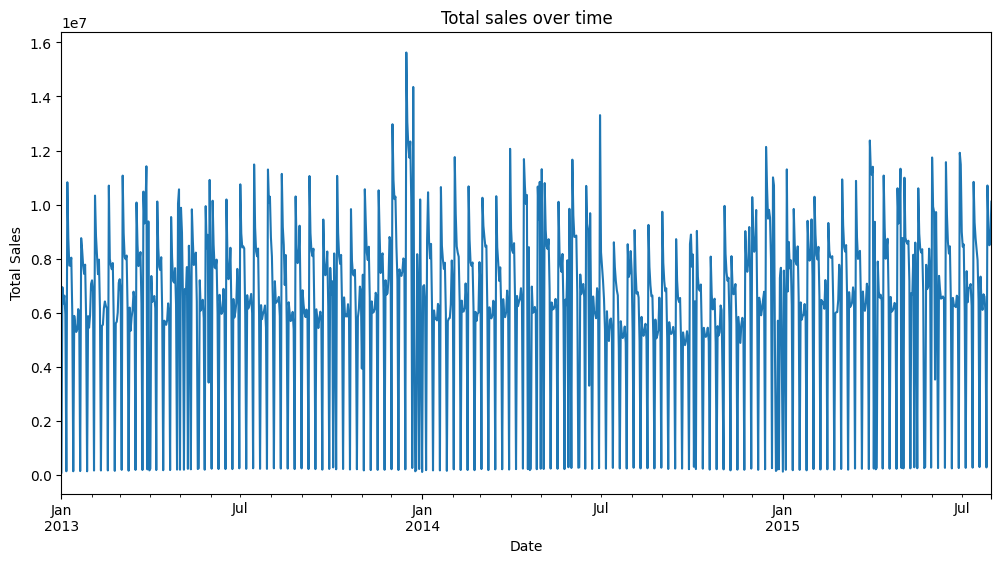

In [32]:
import matplotlib.pyplot as plt
daily_sales = data.groupby('Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
daily_sales.plot()
plt.title('Total sales over time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

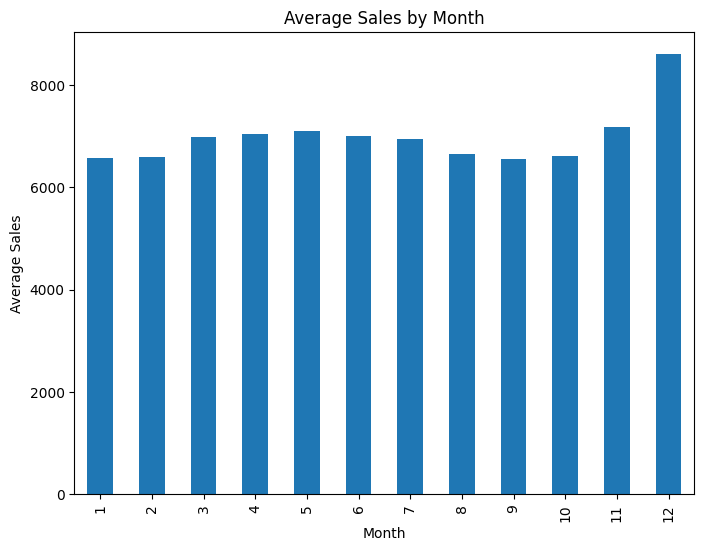

In [33]:
data['Month'] = data['Date'].dt.month
monthly_sales = data.groupby('Month')['Sales'].mean()

monthly_sales.plot(kind='bar', figsize=(8, 6))
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

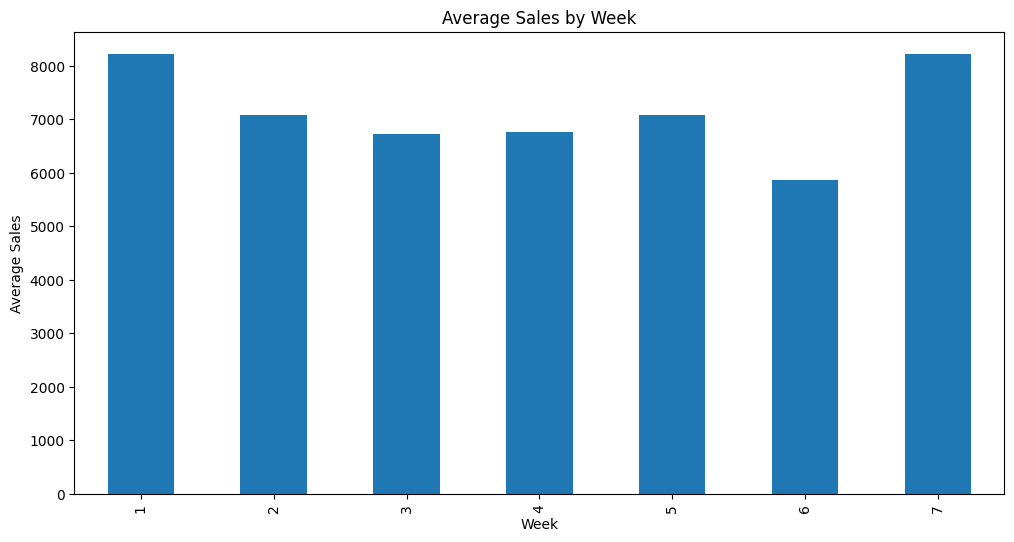

In [36]:
weekly_sales = data.groupby('DayOfWeek')['Sales'].mean()

weekly_sales.plot(kind='bar', figsize=(12, 6))
plt.title('Average Sales by Week')
plt.xlabel('Week')
plt.ylabel('Average Sales')
plt.show()

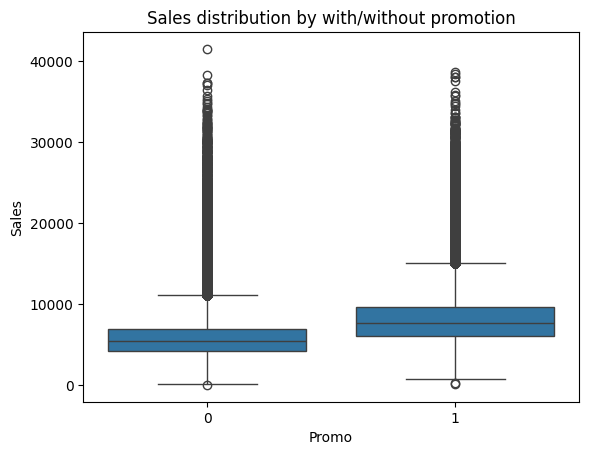

In [40]:
import seaborn as sns
sns.boxplot(x='Promo', y='Sales', data=data)
plt.title('Sales distribution by with/without promotion')
plt.xlabel('Promo')
plt.ylabel('Sales')
plt.show()

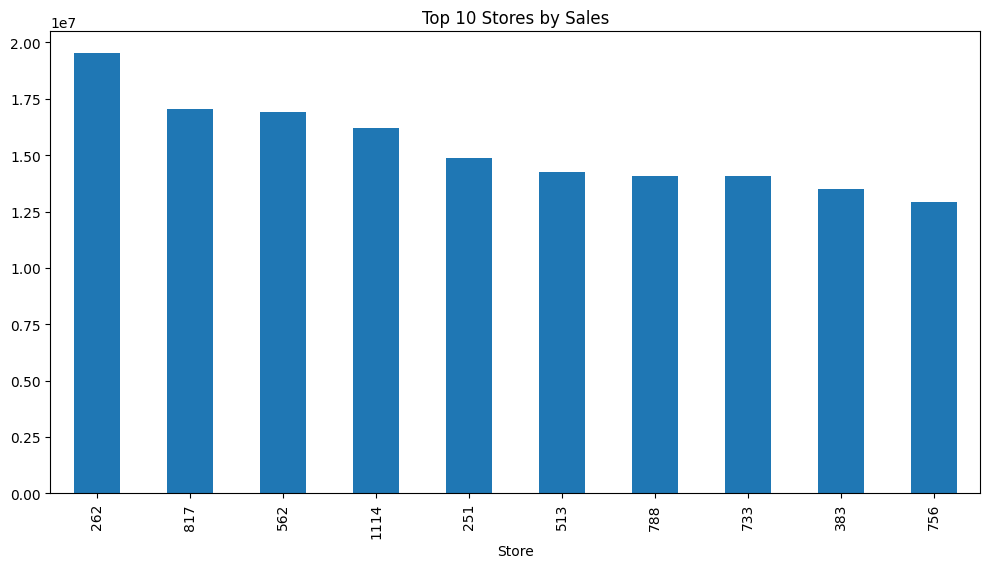

In [41]:
top_stores = data.groupby('Store')['Sales'].sum().sort_values(ascending=False).head(10)
top_stores.plot(kind='bar',figsize=(12,6))
plt.title('Top 10 Stores by Sales')
plt.show()

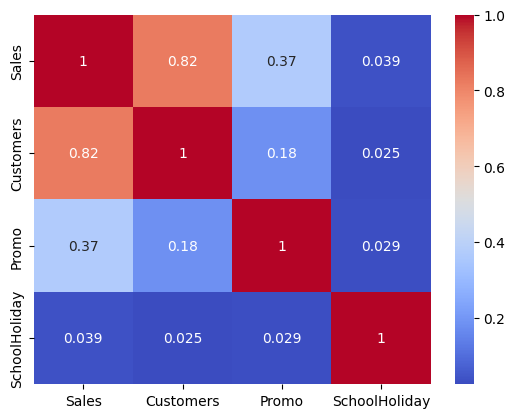

In [43]:
corr = data[['Sales','Customers','Promo','SchoolHoliday']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

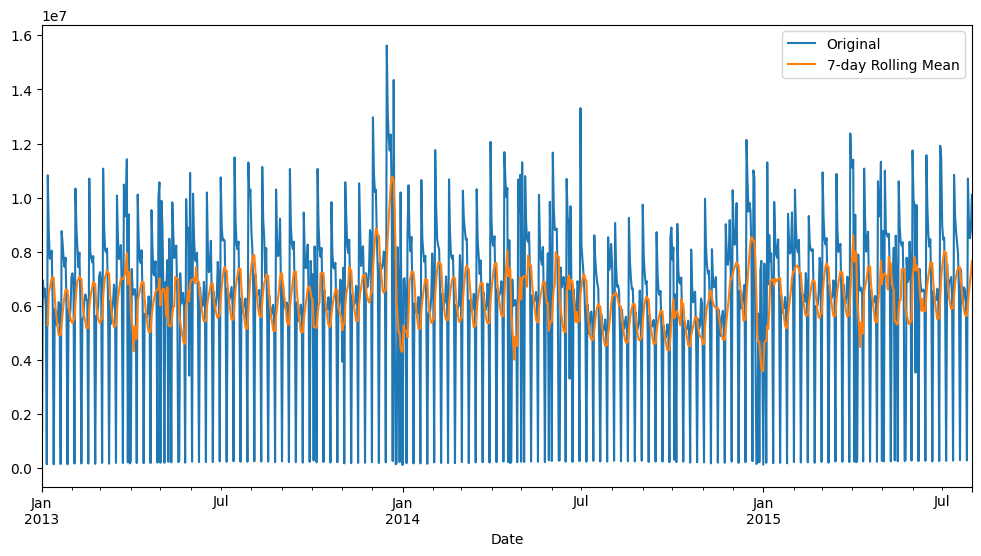

In [44]:
rolling_mean = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12, 6))
daily_sales.plot(label='Original')
rolling_mean.plot(label='7-day Rolling Mean')
plt.legend()
plt.show

In [47]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['WeekOfYear'] = data['Date'].dt.isocalendar().week
data['DayOfWeek'] = data['Date'].dt.dayofweek

In [49]:
data['Is_Weekend'] = data['DayOfWeek'].isin([5,6]).astype(int)

In [50]:
data = data.sort_values(by=['Store','Date'])

data['Lag_1'] = data.groupby('Store')['Sales'].shift(1)
data['Lag_7'] = data.groupby('Store')['Sales'].shift(7)
data['Lag_30'] = data.groupby('Store')['Sales'].shift(30)

In [51]:
data['Rolling_7'] = data.groupby('Store')['Sales'].shift(1).rolling(window=7).mean()
data['Rolling_14'] = data.groupby('Store')['Sales'].shift(1).rolling(window=14).mean()

In [52]:
data = data.dropna()

In [53]:
data = pd.get_dummies(data, columns=['StoreType','Assortment','StateHoliday'], drop_first=True)

In [54]:
data = data.drop(['Date'], axis=1)

In [55]:
X = data.drop('Sales', axis=1)
y = data['Sales']

In [60]:
X_train.select_dtypes(include='object').columns

Index(['PromoInterval'], dtype='object')

In [61]:
data = data.drop('PromoInterval', axis=1)

In [57]:
y_pred_baseline = X_test['Lag_1']

In [63]:
X = data.drop('Sales', axis=1)
y = data['Sales']

train_data = data[data['Year'] < 2015]
test_data  = data[data['Year'] >= 2015]

X_train = train_data.drop('Sales', axis=1)
y_train = train_data['Sales']

X_test = test_data.drop('Sales', axis=1)
y_test = test_data['Sales']

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)

Baseline MAE: 1328.019425847823
Baseline RMSE: 2004.8008434184615


In [64]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [65]:
y_pred = model.predict(X_test)

In [66]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model MAE:", mae)
print("Model RMSE:", rmse)

Model MAE: 556.5971558871179
Model RMSE: 781.7331925578752


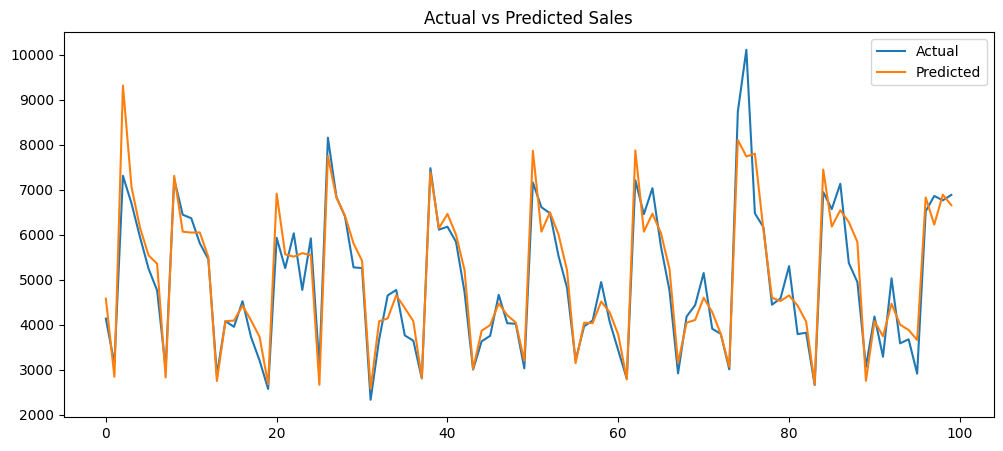

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [68]:
!pip install xgboost

In [69]:
from xgboost import XGBRegressor

In [70]:
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [71]:
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [72]:
y_pred_xgb = model_xgb.predict(X_test)

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 364.7075500488281
XGBoost RMSE: 525.5960307118006


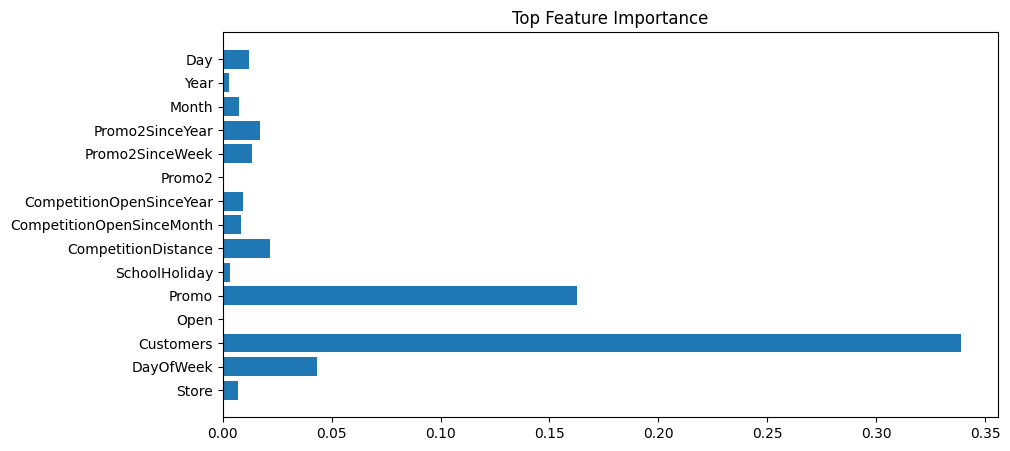

In [74]:
import matplotlib.pyplot as plt

importance = model_xgb.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,5))
plt.barh(features[:15], importance[:15])
plt.title("Top Feature Importance")
plt.show()

In [75]:
import pandas as pd

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
2,Customers,0.338950
4,Promo,0.162631
23,StoreType_d,0.128014
21,Rolling_14,0.088199
17,Lag_1,0.071635
1,DayOfWeek,0.043123
6,CompetitionDistance,0.021815
20,Rolling_7,0.016915
11,Promo2SinceYear,0.016864
10,Promo2SinceWeek,0.013574


In [76]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

In [77]:
xgb = XGBRegressor(random_state=42, n_jobs=-1)

In [79]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,  # try 10 combinations
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [6, 8, 10],
                                        'n_estimators': [200, 300, 400],
                                        'subsample': [0.7, 0.8, 1]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [80]:
print(random_search.best_params_)

{'subsample': 0.7, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [81]:
best_model = random_search.best_estimator_

In [82]:
y_pred_tuned = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("Tuned MAE:", mae_tuned)
print("Tuned RMSE:", rmse_tuned)

Tuned MAE: 511.7284851074219
Tuned RMSE: 730.3441397724774


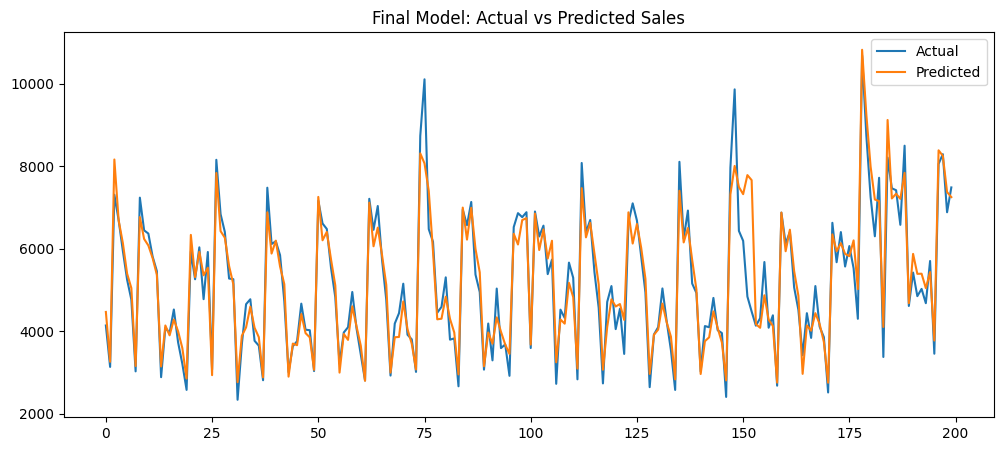

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred_tuned[:200], label='Predicted')
plt.legend()
plt.title("Final Model: Actual vs Predicted Sales")
plt.show()

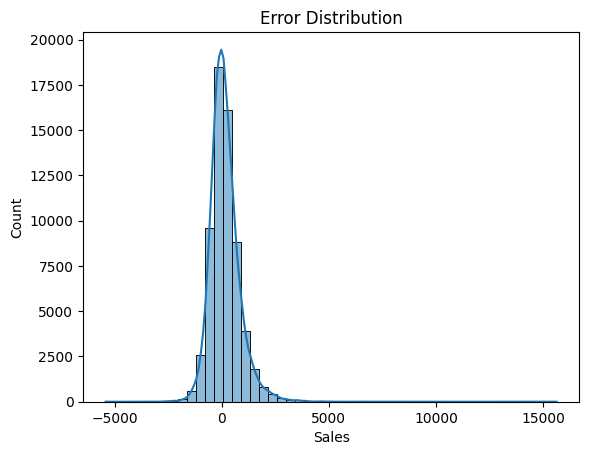

In [84]:
import seaborn as sns

errors = y_test - y_pred_tuned

sns.histplot(errors, bins=50, kde=True)
plt.title("Error Distribution")
plt.show()